### Demographic Comparison of Control and Test Groups

The objective of this analysis is to explore the demographic characteristics of Vanguard's clients and determine whether the Control and Test groups are sufficiently comparable before evaluating the results of the A/B test.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pltun
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
url = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_demo.txt"
df_final_demo = pd.read_csv(url, sep=",")
df_final_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [3]:
url_2 = "https://raw.githubusercontent.com/data-bootcamp-v4/lessons/refs/heads/main/5_6_eda_inf_stats_tableau/project/files_for_project/df_final_experiment_clients.txt"
df_final_experiment_clients = pd.read_csv(url_2, sep=",")
df_final_experiment_clients.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


Clients with a missing `variation` do not have a recorded assignment to either the Control or Test group. Since their experimental condition cannot be determined reliably, we will not attempt to infer or impute their group assignment.

In [4]:
# Merge customer profiles with experimental assignments
df_clients = df_final_demo.merge(df_final_experiment_clients, on="client_id", how="left")

df_clients.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,Control


In [5]:
df_clients.shape

(70609, 10)

In [6]:
df_clients["Variation"].value_counts(dropna=False)

Variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

In [7]:
df_experiment = df_clients[df_clients["Variation"].isin(["Control", "Test"])].copy()

We first explore the demographic characteristics of Vanguard's customers and then compare their distributions between the Control and Test groups.

In [8]:
demographic_variables = ['clnt_age','gendr','clnt_tenure_mnth']

Since `clnt_tenure_yr` and `clnt_tenure_mnth` represent the same concept of customer tenure, tenure in monts will be used for the main demographic analysis to avoid redundant comparisons.

In [9]:
df_experiment[demographic_variables].isna().sum()

clnt_age            13
gendr               12
clnt_tenure_mnth    12
dtype: int64

In [10]:
df_experiment.groupby('Variation')[demographic_variables].count()

,clnt_age,gendr,clnt_tenure_mnth
Variation,,,
Control,23526,23527,23527
Test,26961,26961,26961


#### Client Age

In [11]:
df_experiment["clnt_age"].describe()

count    50487.000000
mean        47.319795
std         15.518616
min         17.000000
25%         33.500000
50%         48.000000
75%         59.500000
max         96.000000
Name: clnt_age, dtype: float64

In [12]:
df_experiment.groupby("Variation")["clnt_age"].describe()

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,23526.0,47.498427,15.521781,17.0,33.5,48.5,60.0,96.0
Test,26961.0,47.163922,15.514461,17.0,33.5,47.5,59.5,96.0


In [13]:
control_age = df_experiment.loc[df_experiment["Variation"] == "Control", "clnt_age"].dropna()
test_age = df_experiment.loc[df_experiment["Variation"] == "Test", "clnt_age"].dropna()

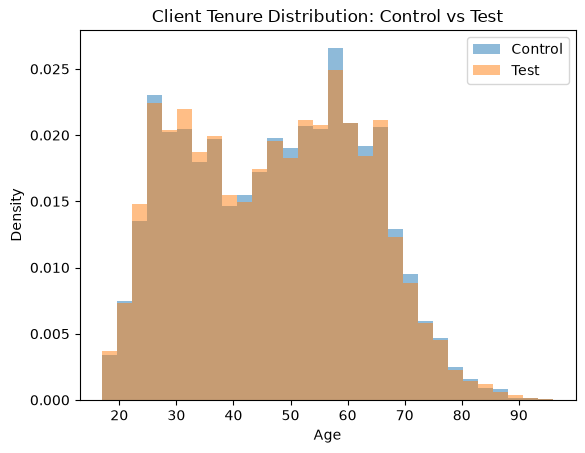

In [14]:
plt.hist(control_age, bins=30, alpha=0.5, density=True, label="Control")
plt.hist(test_age, bins=30, alpha=0.5, density=True, label="Test")
plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Client Tenure Distribution: Control vs Test")
plt.legend()
plt.show()

The age distributions of the Control and Test groups appear very similar. Both groups have the same age range (17–96 years) and almost identical standard deviations. The mean age is 47.50 years in the Control group and 47.16 years in the Test group, while the median is 48.5 and 47.5 years, respectively.

The descriptive statistics and the distribution plot do not show a substantial difference in age between the two groups. 

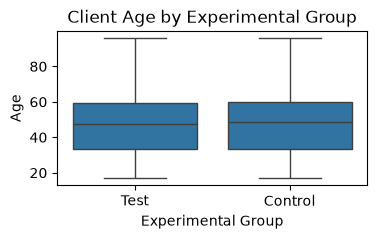

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 2))

sns.boxplot(data=df_experiment, x="Variation", y="clnt_age")

plt.title("Client Age by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Age")
plt.show()

#### Client Gender

Gender is a categorical variable, so we'll use relative frequencies

In [16]:
df_experiment["gendr"].value_counts(dropna=False)

gendr
U      17280
M      16947
F      16259
NaN       12
X          2
Name: count, dtype: int64

In [17]:
gender_distribution = pd.crosstab(df_experiment["gendr"], df_experiment["Variation"], normalize="columns") * 100

gender_distribution

Variation,Control,Test
gendr,,
F,32.061036,32.328178
M,33.875972,33.296243
U,34.062991,34.368161
X,0.000000,0.007418


The gender distribution is very similar between the Control and Test groups. The proportions of F, M and U are almost identical in both groups. The X category is extremely rare, appearing only in the Test group (0.007%).

The dataset documentation does not define the meaning of the U and X categories. Therefore, these categories are treated as recorded categorical values without assigning a specific interpretation.(U could be unspecified gender)

Overall, no substantial differences in the distribution of the recorded gender categories are apparent from the descriptive analysis.

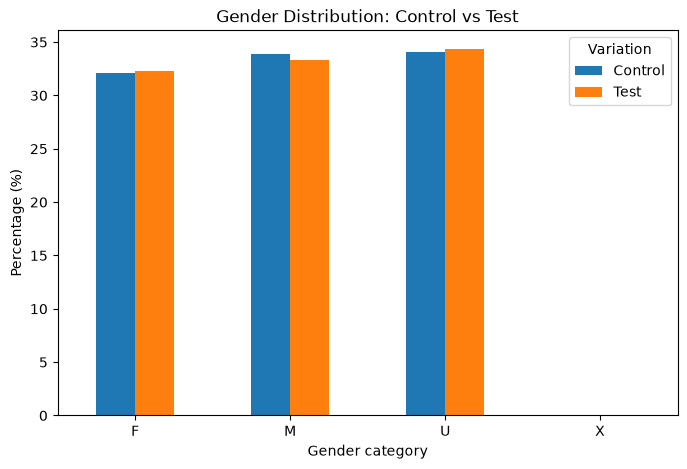

In [18]:
gender_distribution = pd.crosstab(df_experiment["gendr"],df_experiment["Variation"],normalize="columns") * 100

gender_distribution.plot(kind="bar",figsize=(8, 5))

plt.xlabel("Gender category")
plt.ylabel("Percentage (%)")
plt.title("Gender Distribution: Control vs Test")
plt.xticks(rotation=0)
plt.legend(title="Variation")
plt.show()

#### Client tenure

In [19]:
df_experiment.groupby("Variation")["clnt_tenure_mnth"].describe()

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,23527.0,151.060186,82.126443,33.0,82.0,137.0,192.0,669.0
Test,26961.0,149.852899,81.783390,33.0,82.0,134.0,191.0,669.0


In [20]:
df_clients.groupby("Variation", dropna=False)["clnt_tenure_mnth"].describe()

,count,mean,std,min,25%,50%,75%,max
Variation,,,,,,,,
Control,23527.0,151.060186,82.126443,33.0,82.0,137.0,192.0,669.0
Test,26961.0,149.852899,81.783390,33.0,82.0,134.0,191.0,669.0
NaN,20107.0,151.271746,82.451745,33.0,82.0,138.0,193.0,749.0


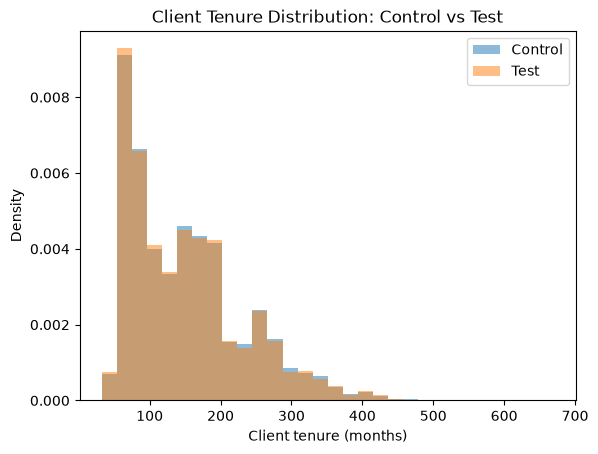

In [21]:
control_tenure = df_experiment.loc[df_experiment["Variation"] == "Control", "clnt_tenure_mnth"].dropna()

test_tenure = df_experiment.loc[df_experiment["Variation"] == "Test", "clnt_tenure_mnth"].dropna()

plt.hist(control_tenure, bins=30, alpha=0.5, density=True, label="Control")
plt.hist(test_tenure, bins=30, alpha=0.5, density=True, label="Test")

plt.xlabel("Client tenure (months)")
plt.ylabel("Density")
plt.title("Client Tenure Distribution: Control vs Test")
plt.legend()
plt.show()

The tenure distributions of the Control and Test groups are very similar. Both groups have the same minimum and maximum values, and their medians are identical at 11 months. The mean tenure is also very similar, with 12.09 months in the Control group and 11.98 months in the Test group. The standard deviations are almost identical.

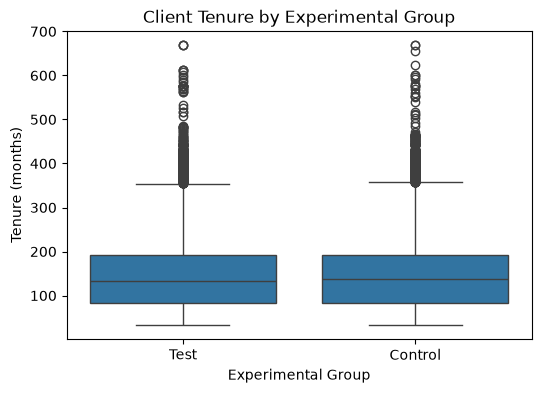

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df_experiment,x="Variation", y="clnt_tenure_mnth")

plt.title("Client Tenure by Experimental Group")
plt.xlabel("Experimental Group")
plt.ylabel("Tenure (months)")
plt.show()

#### Statistical comparison of demographic variables

Descriptive statistics and visualisations provide an initial comparison of the Control and Test groups. However, observed differences may arise from sampling variability.

For each demographic variable, we test the null hypothesis that there is no difference between the Control and Test groups.

The significance level is set at α = 0.05.

If the p-value is below 0.05, we reject the null hypothesis and consider that there is statistical evidence of a difference between the groups. If the p-value is equal to or above 0.05, we fail to reject the null hypothesis.

`clnt_age` is a quantitative variable and we are comparing two independent groups: Control and Test.

We use an independent two-sample t-test to compare the mean age of the two groups.

In [23]:
from scipy.stats import ttest_ind

# H_0: The mean age is equal in the Control and Test groups.
# H_1: The mean age differs between the Control and Test groups.

control_age = df_experiment.loc[df_experiment["Variation"] == "Control","clnt_age"].dropna()
test_age = df_experiment.loc[df_experiment["Variation"] == "Test","clnt_age"].dropna()

age_test = ttest_ind(control_age,test_age,equal_var=False)
age_test

TtestResult(statistic=np.float64(2.416068061200627), pvalue=np.float64(0.015692719461388675), df=np.float64(49556.715189428134))

There is statistically significant evidence of a difference in mean age between the Control and Test groups, but the observed difference is very small and therefore appears to have limited practical relevance.

`clnt_tenure_mnth` is a quantitative variable representing the number of months that a client has been with Vanguard.

As with age, we compare the mean tenure between the Control and Test groups using an independent two-sample t-test.

In [24]:
# H_0: The mean client tenure is equal in the Control and Test groups.
# H_1: The mean client tenure differs between the Control and Test groups.

control_tenure = df_experiment.loc[df_experiment["Variation"] == "Control","clnt_tenure_mnth"].dropna()
test_tenure = df_experiment.loc[df_experiment["Variation"] == "Test","clnt_tenure_mnth"].dropna()

tenure_test = ttest_ind(control_tenure,test_tenure, equal_var=False)

tenure_test

TtestResult(statistic=np.float64(1.650935593639794), pvalue=np.float64(0.09875806956295248), df=np.float64(49508.334440286395))

Since the p-value is above the significance level of α = 0.05, we fail to reject the null hypothesis. Therefore, there is not sufficient statistical evidence to conclude that the mean client tenure differs between the Control and Test groups.

The descriptive statistics also showed very similar tenure values between the two groups, with a mean difference of approximately 0.11 months.

`gendr` is a categorical variable with four recorded categories: F, M, U and X. 

A Chi-square test of independence is used to assess whether the distribution of the recorded gender categories is associated with the experimental group.

The test compares the observed frequencies in the Control and Test groups with the frequencies that would be expected if gender category and experimental group were independent.

In [25]:
# H_0: The distribution of the recorded gender categories is independent of the experimental group.
# H_1: The distribution of the recorded gender categories differs between the Control and Test groups.

gender_table = pd.crosstab(df_experiment["gendr"],df_experiment["Variation"])
gender_table

Variation,Control,Test
gendr,,
F,7543,8716
M,7970,8977
U,8014,9266
X,0,2


In [28]:
chi2, p_value, dof, expected = stats.chi2_contingency(gender_table)
chi2, p_value

(np.float64(3.6234732250942896), np.float64(0.30509759398220404))

Since the p-value is above the significance level of α = 0.05, we fail to reject the null hypothesis. Therefore, there is not sufficient statistical evidence to conclude that the distribution of the recorded gender categories differs between the Control and Test groups.

This suggests that gender distribution is not statistically different between the two experimental groups.

### Conclusion - Demographic variables

The descriptive and statistical analyses provide an overall comparison of the demographic characteristics of the Control and Test groups.

For client age, the statistical test indicates a statistically significant difference between the groups. However, the difference in mean age is very small, with mean ages of 47.50 years in the Control group and 47.16 years in the Test group. The age distributions are also very similar, suggesting that this statistically significant difference has limited practical relevance.

For client tenure, we did not find sufficient statistical evidence of a difference between the groups. Similarly, the Chi-square test for gender did not provide evidence of a different gender distribution between the Control and Test groups.

Overall, although a statistically significant difference was detected for age, the magnitude of this difference is very small. Therefore, based on the demographic variables analysed, there is no evidence of a meaningful imbalance between the Control and Test groups that would substantially affect the comparison of the experiment.